<a href="https://colab.research.google.com/github/GowrishankarSMenon/Fine-Tuning-Practice/blob/first_test/Fine_Tuning_Cat_vs_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow keras

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import urllib.request
import zipfile
import os
import shutil

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [ ]:
# Download the dataset
url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
zip_path = "cats_and_dogs.zip"

print("Downloading dataset...")
urllib.request.urlretrieve(url, zip_path)

# Extract the zip file
print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('.')

print("Download and extraction complete!")

Extracting dataset...
Download and extraction complete!


In [ ]:
# Create directory structure
os.makedirs('cats_and_dogs_filtered/train/cats', exist_ok=True)
os.makedirs('cats_and_dogs_filtered/train/dogs', exist_ok=True)
os.makedirs('cats_and_dogs_filtered/validation/cats', exist_ok=True)
os.makedirs('cats_and_dogs_filtered/validation/dogs', exist_ok=True)

# Organize files (80% train, 20% validation)
for animal in ['Cat', 'Dog']:
    source_dir = f'PetImages/{animal}'
    if os.path.exists(source_dir):
        files = [f for f in os.listdir(source_dir) if f.endswith('.jpg')]
        split_idx = int(len(files) * 0.8)

        print(f"Processing {animal}s: {len(files)} images")

        # Training files
        for i, file in enumerate(files[:split_idx]):
            src = os.path.join(source_dir, file)
            dst = f'cats_and_dogs_filtered/train/{animal.lower()}s/{file}'
            try:
                shutil.copy(src, dst)
            except:
                pass

        # Validation files
        for file in files[split_idx:]:
            src = os.path.join(source_dir, file)
            dst = f'cats_and_dogs_filtered/validation/{animal.lower()}s/{file}'
            try:
                shutil.copy(src, dst)
            except:
                pass

print("\nDataset organization complete!")

# Count files
train_cats = len(os.listdir('cats_and_dogs_filtered/train/cats'))
train_dogs = len(os.listdir('cats_and_dogs_filtered/train/dogs'))
val_cats = len(os.listdir('cats_and_dogs_filtered/validation/cats'))
val_dogs = len(os.listdir('cats_and_dogs_filtered/validation/dogs'))

print(f"\nTrain - Cats: {train_cats}, Dogs: {train_dogs}")
print(f"Validation - Cats: {val_cats}, Dogs: {val_dogs}")

Processing Cats: 12500 images
Processing Dogs: 12500 images

Dataset organization complete!

Train - Cats: 10000, Dogs: 10000
Validation - Cats: 2500, Dogs: 2500


In [ ]:
# Clean corrupted images from the dataset
from PIL import Image
import os

def remove_corrupted_images(directory):
    """Remove corrupted or invalid image files"""
    removed_count = 0

    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.jpg') or file.endswith('.jpeg') or file.endswith('.png'):
                filepath = os.path.join(root, file)
                try:
                    # Try to open and verify the image
                    img = Image.open(filepath)
                    img.verify()  # Verify it's a valid image
                    img.close()

                    # Also check if image can be loaded properly
                    img = Image.open(filepath)
                    img.load()
                    img.close()

                except Exception as e:
                    # If any error occurs, remove the file
                    print(f"Removing corrupted file: {filepath}")
                    os.remove(filepath)
                    removed_count += 1

    return removed_count

# Clean both train and validation directories
print("Cleaning corrupted images from training data...")
train_removed = remove_corrupted_images('cats_and_dogs_filtered/train')

print("Cleaning corrupted images from validation data...")
val_removed = remove_corrupted_images('cats_and_dogs_filtered/validation')

print(f"\nTotal corrupted images removed: {train_removed + val_removed}")
print(f"  - From training: {train_removed}")
print(f"  - From validation: {val_removed}")

# Recount files after cleaning
train_cats = len(os.listdir('cats_and_dogs_filtered/train/cats'))
train_dogs = len(os.listdir('cats_and_dogs_filtered/train/dogs'))
val_cats = len(os.listdir('cats_and_dogs_filtered/validation/cats'))
val_dogs = len(os.listdir('cats_and_dogs_filtered/validation/dogs'))

print(f"\nClean dataset counts:")
print(f"Train - Cats: {train_cats}, Dogs: {train_dogs}")
print(f"Validation - Cats: {val_cats}, Dogs: {val_dogs}")

Cleaning corrupted images from training data...
Removing corrupted file: cats_and_dogs_filtered/train/cats/666.jpg
Removing corrupted file: cats_and_dogs_filtered/train/dogs/11702.jpg
Cleaning corrupted images from validation data...

Total corrupted images removed: 2
  - From training: 2
  - From validation: 0

Clean dataset counts:
Train - Cats: 9999, Dogs: 9999
Validation - Cats: 2500, Dogs: 2500


In [ ]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

train_dir = "cats_and_dogs_filtered/train"
val_dir = "cats_and_dogs_filtered/validation"

# Create data generators with augmentation for training
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_gen = ImageDataGenerator(rescale=1./255)

# Create data iterators
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

print(f"\nTraining samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Classes: {train_data.class_indices}")

Found 19998 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.

Training samples: 19998
Validation samples: 5000
Classes: {'cats': 0, 'dogs': 1}


In [ ]:
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 243s 384ms/step - accuracy: 0.8999 - loss: 0.2202 - val_accuracy: 0.9750 - val_loss: 0.0674
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 238s 381ms/step - accuracy: 0.9594 - loss: 0.1026 - val_accuracy: 0.9796 - val_loss: 0.0579
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 240s 384ms/step - accuracy: 0.9648 - loss: 0.0897 - val_accuracy: 0.9712 - val_loss: 0.0715
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 237s 379ms/step - accuracy: 0.9660 - loss: 0.0909 - val_accuracy: 0.9756 - val_loss: 0.0668
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 235s 377ms/step - accuracy: 0.9626 - loss: 0.0906 - val_accuracy: 0.9780 - val_loss: 0.0595


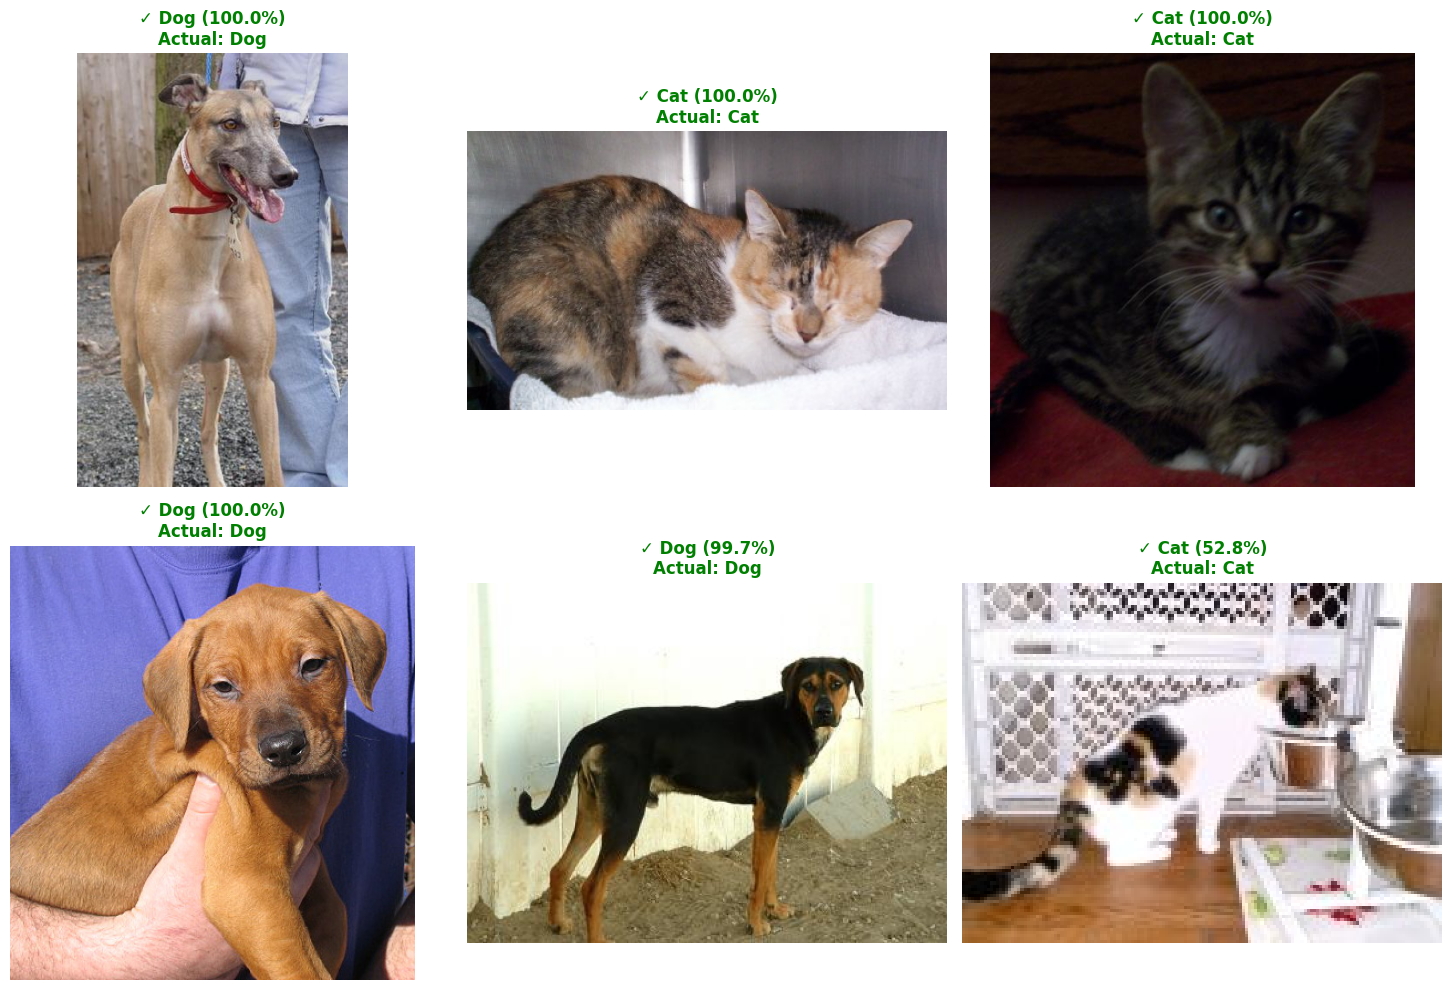


Accuracy on these 6 samples: 6/6 (100.0%)


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Get random images from validation set
val_cats_dir = "cats_and_dogs_filtered/validation/cats"
val_dogs_dir = "cats_and_dogs_filtered/validation/dogs"

cat_images = [os.path.join(val_cats_dir, f) for f in os.listdir(val_cats_dir) if f.endswith('.jpg')]
dog_images = [os.path.join(val_dogs_dir, f) for f in os.listdir(val_dogs_dir) if f.endswith('.jpg')]

# Sample 3 cats and 3 dogs randomly
test_images = random.sample(cat_images, 3) + random.sample(dog_images, 3)
true_labels = ["Cat"] * 3 + ["Dog"] * 3

# Shuffle them together
combined = list(zip(test_images, true_labels))
random.shuffle(combined)
test_images, true_labels = zip(*combined)

# Create a grid of predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (img_path, true_label) in enumerate(zip(test_images, true_labels)):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = model.predict(img_array, verbose=0)

    # Interpret prediction
    if prediction[0][0] > 0.5:
        predicted_label = "Dog"
        confidence = prediction[0][0]
    else:
        predicted_label = "Cat"
        confidence = 1 - prediction[0][0]

    # Display
    axes[idx].imshow(image.load_img(img_path))
    axes[idx].axis('off')

    is_correct = "✓" if predicted_label == true_label else "✗"
    color = 'green' if predicted_label == true_label else 'red'
    axes[idx].set_title(f'{is_correct} {predicted_label} ({confidence:.1%})\nActual: {true_label}',
                        color=color, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Calculate accuracy on these samples
correct = sum(1 for img_path, true_label in zip(test_images, true_labels)
              if ((model.predict(np.expand_dims(image.img_to_array(image.load_img(img_path, target_size=IMG_SIZE))/255.0, axis=0), verbose=0)[0][0] > 0.5 and true_label == "Dog") or
                  (model.predict(np.expand_dims(image.img_to_array(image.load_img(img_path, target_size=IMG_SIZE))/255.0, axis=0), verbose=0)[0][0] <= 0.5 and true_label == "Cat")))

print(f"\nAccuracy on these {len(test_images)} samples: {correct}/{len(test_images)} ({correct/len(test_images)*100:.1f}%)")